# Whitevox Revenue Forecasting

This notebook builds and evaluates a forecasting model for Whitevox's monthly
revenue, then persists the winning artifacts for the companion Streamlit app
(`app.py`).

**Data**
- `data/whitevox_company_monthly_kpis.csv` — one row per month, company-wide roll-up.
- `data/whitevox_monthly_by_service_line.csv` — one row per (month, service_line);
  10 service lines, each with its own launch date.

**Approach**
1. Explore the data and confirm the patterns we expect (trend, seasonality, shocks, a cold-start service line).
2. Engineer features with strict no-leakage rules (see the markdown cell before feature engineering).
3. Compare three forecasting approaches on a 12-month, time-based holdout: seasonal naive, SARIMAX, and XGBoost.
4. Also build a per-service-line XGBoost model, and check whether summing its forecasts reconciles to the company total.
5. Forecast forward and save the deployable artifacts.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from xgboost import XGBRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX

import forecasting_lib as flib

%matplotlib inline
plt.rcParams["figure.figsize"] = (11, 4)
pd.set_option("display.max_columns", 50)


## 1. Load & explore

In [2]:
df_company = flib.load_company_df()
df_service = flib.load_service_df()

print("Company:", df_company.shape, df_company["date"].min().date(), "to", df_company["date"].max().date())
print("Service (long format):", df_service.shape)
df_company.head()


Company: (104, 13) 2018-01-01 to 2026-08-01
Service (long format): (1040, 10)


,date,total_revenue_usd,total_marketing_spend_usd,total_new_clients,total_churned_clients,total_active_clients,total_new_leads,total_projects_completed,headcount,website_organic_sessions,avg_client_csat,inbound_mqls,gross_margin_pct
0,2018-01-01,83895.77,8197.18,6,0,19,54,17,20,9039,4.07,84,0.36
1,2018-02-01,73094.79,6144.62,4,1,22,32,16,20,9478,4.03,51,0.32
2,2018-03-01,74632.64,8889.95,6,0,28,44,17,23,9271,4.14,63,0.35
3,2018-04-01,74262.79,6161.94,6,1,33,53,14,23,9416,4.06,74,0.30
4,2018-05-01,77904.98,7289.18,3,3,33,31,21,24,9614,4.17,41,0.33


In [3]:
df_service.head()


,date,service_line,active_clients,new_clients,churned_clients,new_leads,revenue_usd,marketing_spend_usd,projects_completed,avg_deal_size_usd
0,2018-01-01,Celebrity Management,0,0,0,0,0.0,0.0,0,0.0
1,2018-02-01,Celebrity Management,0,0,0,0,0.0,0.0,0,0.0
2,2018-03-01,Celebrity Management,0,0,0,0,0.0,0.0,0,0.0
3,2018-04-01,Celebrity Management,0,0,0,0,0.0,0.0,0,0.0
4,2018-05-01,Celebrity Management,0,0,0,0,0.0,0.0,0,0.0


In [4]:
# Confirm each service line's launch date (first month with non-zero revenue)
launches = (
    df_service[df_service["revenue_usd"] > 0]
    .groupby("service_line")["date"].min()
    .sort_values()
)
launches.to_frame("launch_month")


,launch_month
service_line,
Online Reputation Management,2018-01-01
PPC / Paid Media,2018-01-01
SEO Services,2018-01-01
Web & Software Development,2018-01-01
Social Media Marketing,2018-06-01
Digital PR,2019-01-01
Influencer Marketing,2019-06-01
Staff Augmentation,2020-01-01
Celebrity Management,2021-01-01


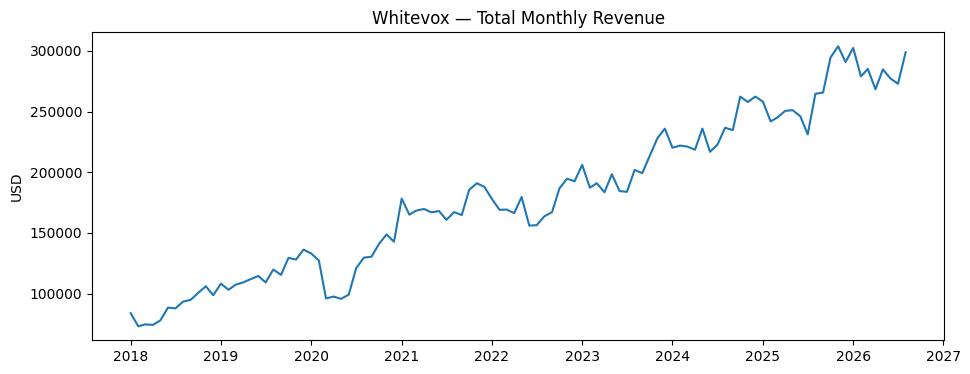

In [5]:
fig, ax = plt.subplots()
ax.plot(df_company["date"], df_company["total_revenue_usd"])
ax.set_title("Whitevox — Total Monthly Revenue")
ax.set_ylabel("USD")
plt.show()


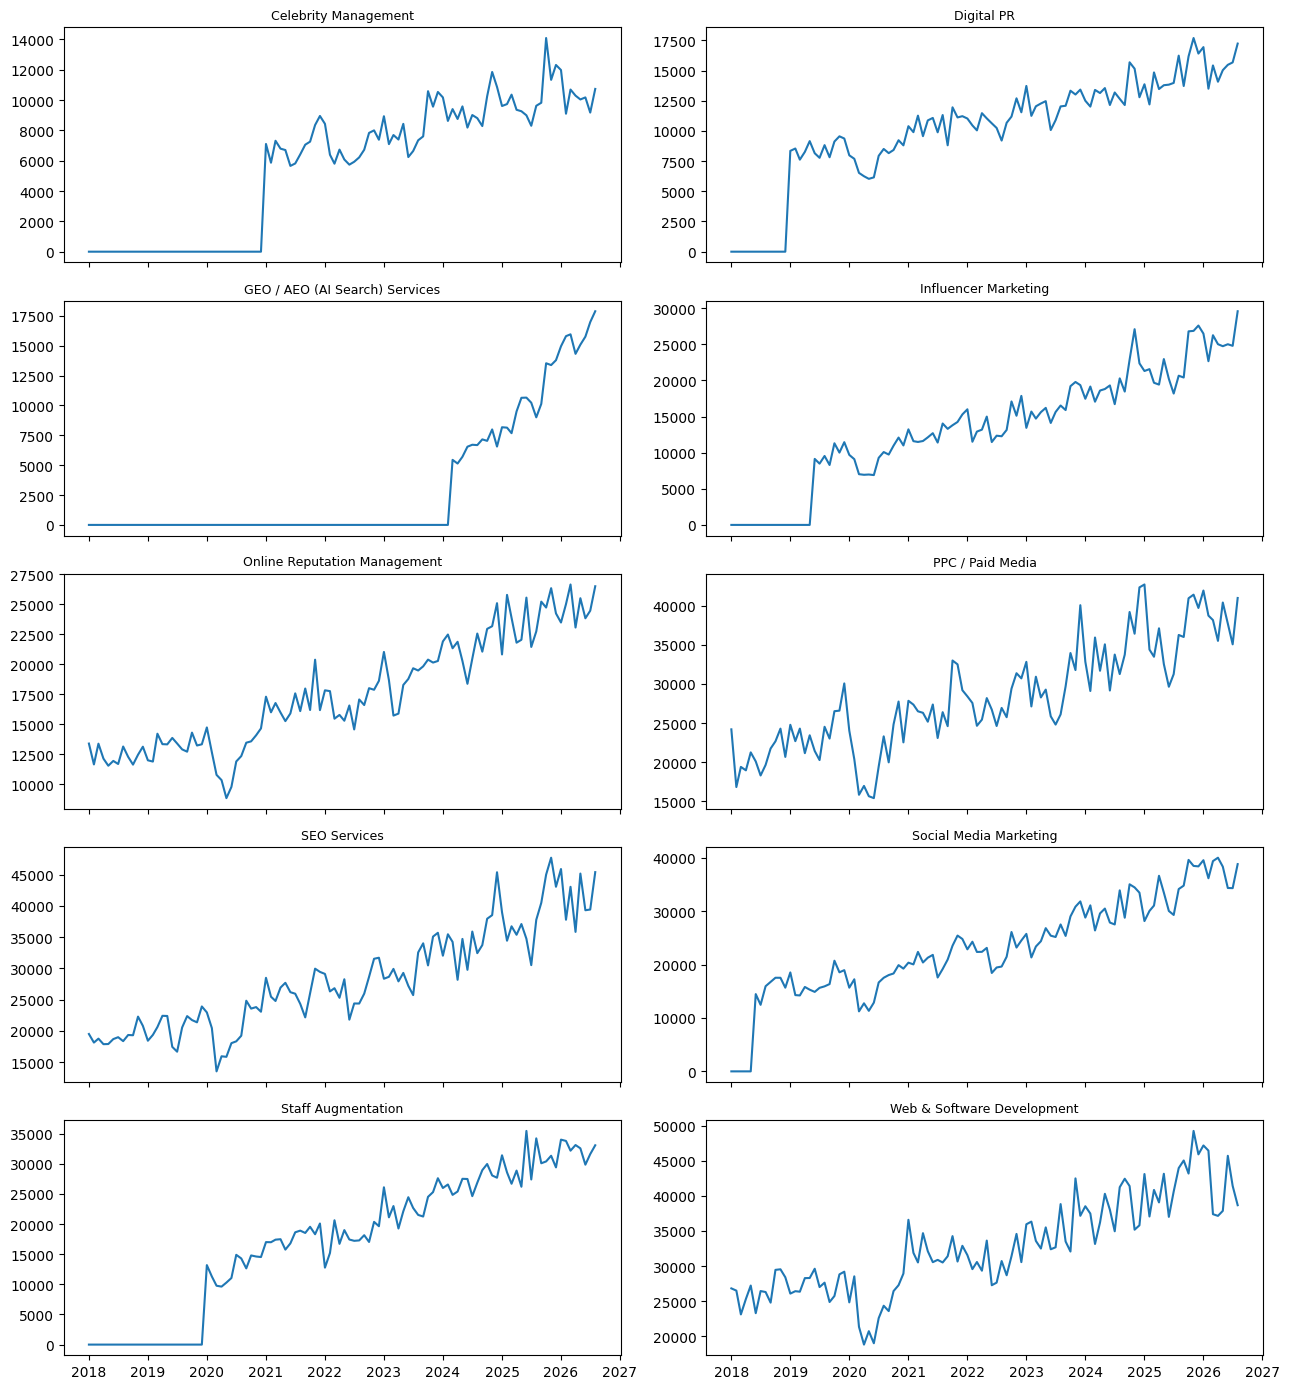

In [6]:
lines = flib.get_service_lines(df_service)
fig, axes = plt.subplots(5, 2, figsize=(13, 14), sharex=True)
for ax, line in zip(axes.ravel(), lines):
    g = df_service[df_service["service_line"] == line]
    ax.plot(g["date"], g["revenue_usd"])
    ax.set_title(line, fontsize=9)
plt.tight_layout()
plt.show()


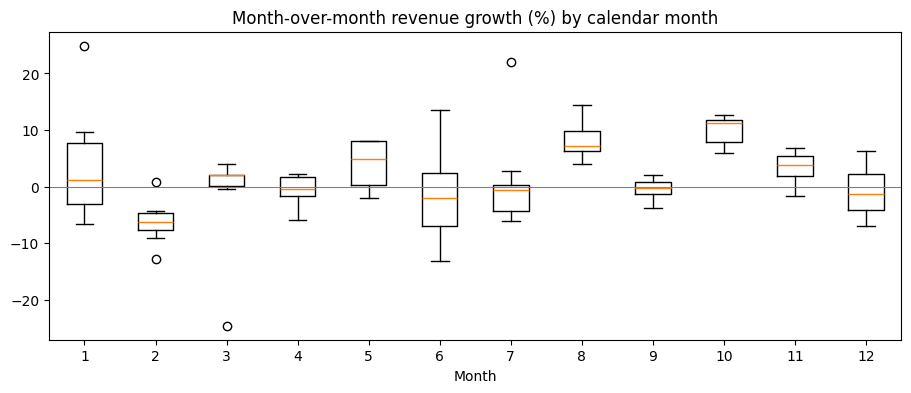

In [7]:
# Seasonality: month-of-year distribution of company revenue growth (MoM %)
mom_growth = df_company.set_index("date")["total_revenue_usd"].pct_change() * 100
by_month = mom_growth.groupby(mom_growth.index.month)

fig, ax = plt.subplots()
ax.boxplot([by_month.get_group(m).dropna() for m in range(1, 13)], labels=range(1, 13))
ax.axhline(0, color="grey", lw=0.8)
ax.set_title("Month-over-month revenue growth (%) by calendar month")
ax.set_xlabel("Month")
plt.show()


In [8]:
# Do leads/spend lead future revenue? Correlate this month's leads/spend with NEXT month's revenue.
check = df_company[["date", "total_new_leads", "total_marketing_spend_usd", "total_revenue_usd"]].copy()
check["revenue_next_month"] = check["total_revenue_usd"].shift(-1)
check[["total_new_leads", "total_marketing_spend_usd", "revenue_next_month"]].corr()


,total_new_leads,total_marketing_spend_usd,revenue_next_month
total_new_leads,1.000000,0.807471,0.837398
total_marketing_spend_usd,0.807471,1.000000,0.952897
revenue_next_month,0.837398,0.952897,1.000000


## 2. Feature engineering — trend + residual design

**Why not feed XGBoost raw revenue directly?** Whitevox's revenue is a strongly,
near-monotonically trending series (it roughly quadruples over the 8.5-year
history). Tree-based models like XGBoost **cannot extrapolate** — a leaf's output
is the mean of training targets that landed in it, so the model can never predict
a value larger than anything it saw during training. Fed raw revenue, it
systematically *underforecasts* every month beyond the training window (we
confirmed this empirically below the first time through — MAPE was roughly double
what the fix below achieves).

**Fix**: fit a simple log-linear trend (`log1p(revenue) ~ t_index (+ t_index²)`)
with plain linear regression, which extrapolates perfectly well. Then train
XGBoost only on the **residual** — how far actual revenue deviates from that
trend, driven by seasonality and lead/spend dynamics. The residual is stationary
(bounded, doesn't grow over time), which is exactly the kind of target trees
handle well. Final forecast = trend + predicted residual.

**Leakage rules enforced throughout `forecasting_lib.py`:**
- All revenue lag/rolling features are computed with `.shift(1)` or later — nothing at
  time *t* uses information only available at or after time *t*.
- `total_new_leads`, `inbound_mqls`, and `total_marketing_spend_usd` are **lagged by 1
  month** before use, since they're recognized in the same reporting period as revenue
  and would otherwise leak same-month information into the model.
- `headcount` is used contemporaneously — staffing levels are a planned business input
  decided ahead of time, not a byproduct of that month's revenue, so this is not a
  leakage risk.
- The trend line itself is fit **only on the training portion** of the holdout split
  (see below), so the holdout evaluation never benefits from seeing its own future.


In [9]:
HOLDOUT = flib.HOLDOUT_MONTHS  # 12 months held out for evaluation
print("Holdout months:", HOLDOUT)

# Fit the trend on the TRAINING portion only (no peeking at the holdout)
train_only_c, _ = flib.time_split(df_company, HOLDOUT)
company_trend = flib.fit_trend(np.arange(len(train_only_c)), train_only_c[flib.COMPANY_TARGET_COL].to_numpy())

feat_company = flib.build_company_features(df_company, company_trend)
feat_company_model = feat_company.dropna(subset=flib.COMPANY_FEATURE_COLS).reset_index(drop=True)
train_c, test_c = flib.time_split(feat_company_model, HOLDOUT)

print("Train shape:", train_c.shape, "| Test shape:", test_c.shape)
feat_company_model[["date", "total_revenue_usd", "trend_log", "resid"] + flib.COMPANY_FEATURE_COLS].tail()


Holdout months: 12
Train shape: (80, 29) | Test shape: (12, 29)


,date,total_revenue_usd,trend_log,resid,resid_lag_1,resid_lag_3,resid_lag_6,resid_lag_12,resid_roll_mean_3,resid_roll_mean_12,month_sin,month_cos,quarter,leads_log_lag_1,mqls_log_lag_1,spend_log_lag_1,headcount
87,2026-04-01,268383.12,12.490061,0.010113,0.075950,0.145751,0.136563,0.014124,0.093761,0.057811,8.660254e-01,-0.500000,2,4.744932,5.147494,10.154488,83
88,2026-05-01,284749.24,12.495194,0.064174,0.010113,0.059582,0.161822,0.009399,0.048549,0.057477,5.000000e-01,-0.866025,2,4.595120,5.030438,10.260617,83
89,2026-06-01,277167.38,12.500186,0.032195,0.064174,0.075950,0.112356,-0.017398,0.050079,0.062041,1.224647e-16,-1.000000,2,4.875197,5.181784,10.303117,84
90,2026-07-01,272893.26,12.505037,0.011802,0.032195,0.010113,0.145751,-0.086430,0.035494,0.066174,-5.000000e-01,-0.866025,3,4.744932,5.187386,10.199105,84
91,2026-08-01,298877.02,12.509749,0.098042,0.011802,0.064174,0.059582,0.042070,0.036057,0.074360,-8.660254e-01,-0.500000,3,4.875197,5.236442,10.235235,86


## 3. Model comparison on the 12-month holdout

In [10]:
X_train_c, y_train_c = train_c[flib.COMPANY_FEATURE_COLS], train_c[flib.COMPANY_RESID_COL]
X_test_c, y_test_c = test_c[flib.COMPANY_FEATURE_COLS], test_c[flib.COMPANY_RESID_COL]

# --- Baseline: seasonal naive (this month = same month last year) ---
naive_pred = flib.seasonal_naive_forecast(feat_company_model[flib.COMPANY_TARGET_COL], HOLDOUT)
naive_metrics = flib.regression_metrics(test_c[flib.COMPANY_TARGET_COL], naive_pred)
naive_metrics


{'MAE': 34763.02, 'RMSE': 35544.12, 'MAPE_%': 12.15}

In [11]:
# --- Classical: SARIMAX on total_revenue_usd ---
# (Prophet was considered but skipped here in favor of SARIMAX, which needs no
# extra system dependencies and handles this series' trend + yearly seasonality directly.)
train_series = feat_company_model.iloc[:-HOLDOUT][flib.COMPANY_TARGET_COL]
sarimax_model = SARIMAX(
    train_series, order=(1, 1, 1), seasonal_order=(1, 1, 0, 12),
    enforce_stationarity=False, enforce_invertibility=False,
).fit(disp=False)
sarimax_pred = sarimax_model.forecast(HOLDOUT).to_numpy()
sarimax_metrics = flib.regression_metrics(test_c[flib.COMPANY_TARGET_COL], sarimax_pred)
sarimax_metrics


{'MAE': 8521.71, 'RMSE': 11035.84, 'MAPE_%': 2.93}

In [12]:
# --- ML: XGBoost on trend-residual features ---
xgb_company = XGBRegressor(
    n_estimators=300, max_depth=3, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42,
)
xgb_company.fit(X_train_c, y_train_c)

resid_pred = xgb_company.predict(X_test_c)
xgb_revenue_pred = np.expm1(test_c["trend_log"].to_numpy() + resid_pred)
xgb_metrics = flib.regression_metrics(test_c[flib.COMPANY_TARGET_COL], xgb_revenue_pred)
xgb_metrics


{'MAE': 18520.92, 'RMSE': 21351.96, 'MAPE_%': 6.39}

In [13]:
comparison = pd.DataFrame(
    [naive_metrics, sarimax_metrics, xgb_metrics],
    index=["Seasonal Naive", "SARIMAX", "XGBoost (trend+residual)"],
)
comparison


,MAE,RMSE,MAPE_%
Seasonal Naive,34763.02,35544.12,12.15
SARIMAX,8521.71,11035.84,2.93
XGBoost (trend+residual),18520.92,21351.96,6.39


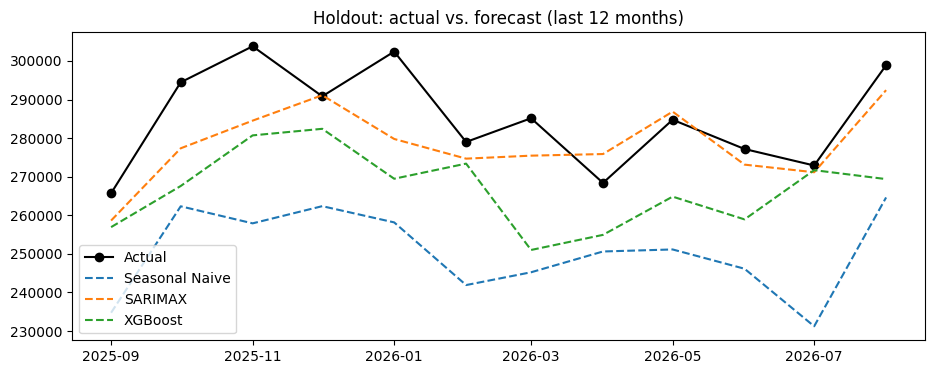

In [14]:
fig, ax = plt.subplots()
ax.plot(test_c["date"], test_c["total_revenue_usd"], "o-", label="Actual", color="black")
ax.plot(test_c["date"], naive_pred, "--", label="Seasonal Naive")
ax.plot(test_c["date"], sarimax_pred, "--", label="SARIMAX")
ax.plot(test_c["date"], xgb_revenue_pred, "--", label="XGBoost")
ax.set_title("Holdout: actual vs. forecast (last 12 months)")
ax.legend()
plt.show()


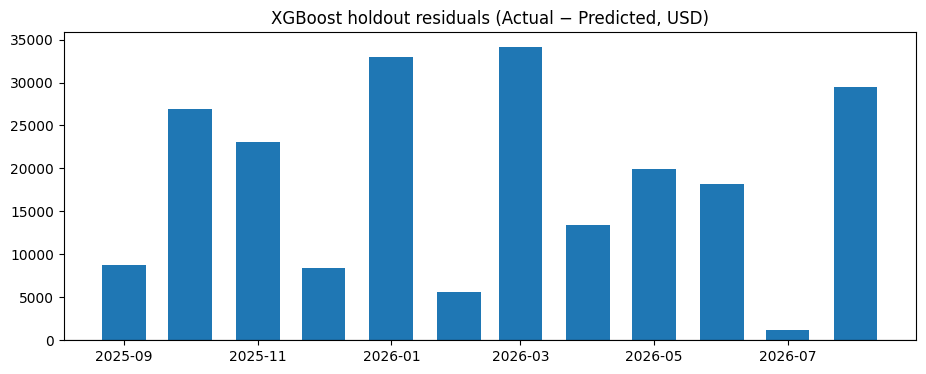

In [15]:
# Residual analysis for the XGBoost model
resid_error = test_c[flib.COMPANY_TARGET_COL].to_numpy() - xgb_revenue_pred
fig, ax = plt.subplots()
ax.bar(test_c["date"], resid_error, width=20)
ax.axhline(0, color="black", lw=0.8)
ax.set_title("XGBoost holdout residuals (Actual − Predicted, USD)")
plt.show()


**Reading the comparison table**: on this data, **SARIMAX** achieves the lowest
MAPE. That's a reasonable outcome — the synthetic revenue series is a fairly
smooth compounding trend with clean yearly seasonality, which is exactly what
SARIMAX is built for. XGBoost improves substantially over feeding it raw revenue
(see the design note above) and over the naive baseline, but doesn't beat a
well-specified SARIMAX here.

**Why we still deploy XGBoost in the Streamlit app** rather than SARIMAX:
SARIMAX in this notebook is univariate (no exogenous drivers), so it can't answer
"what if we increase marketing spend by 20%?" — a scenario-planning feature the
app needs. XGBoost's feature set includes lagged leads/spend, so it supports that
what-if analysis directly. This is a deliberate accuracy-vs-capability trade-off;
see the README for the full reasoning. If scenario planning weren't required,
SARIMAX (or a SARIMAX with exogenous regressors) would be the better default.


## 4. Per-service-line model

In [16]:
df_service_post = flib.restrict_to_post_launch(df_service)
service_trends = flib.fit_service_trends(df_service_post, HOLDOUT)  # trend fit on each line's TRAIN portion only
feat_service = flib.build_service_features(df_service, service_trends)
train_s, test_s = flib.time_split_panel(feat_service, HOLDOUT)
print("Train:", train_s.shape, "Test:", test_s.shape)

X_train_s, y_train_s = train_s[flib.SERVICE_FEATURE_COLS], train_s[flib.SERVICE_RESID_COL]
X_test_s, y_test_s = test_s[flib.SERVICE_FEATURE_COLS], test_s[flib.SERVICE_RESID_COL]

xgb_service = XGBRegressor(
    n_estimators=400, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42,
    enable_categorical=True, tree_method="hist",
)
xgb_service.fit(X_train_s, y_train_s)

service_resid_pred = xgb_service.predict(X_test_s)
trend_log_test_s = np.log1p(test_s[flib.SERVICE_TARGET_COL]) - test_s[flib.SERVICE_RESID_COL]
service_revenue_pred = np.expm1(trend_log_test_s + service_resid_pred)
service_metrics = flib.regression_metrics(test_s[flib.SERVICE_TARGET_COL], service_revenue_pred)
service_metrics


Train: (752, 22) Test: (120, 22)


{'MAE': 2098.69, 'RMSE': 2742.52, 'MAPE_%': 8.09}

Sum-of-lines vs. company-total MAPE: {'MAE': 8829.19, 'RMSE': 9930.07, 'MAPE_%': 3.06}


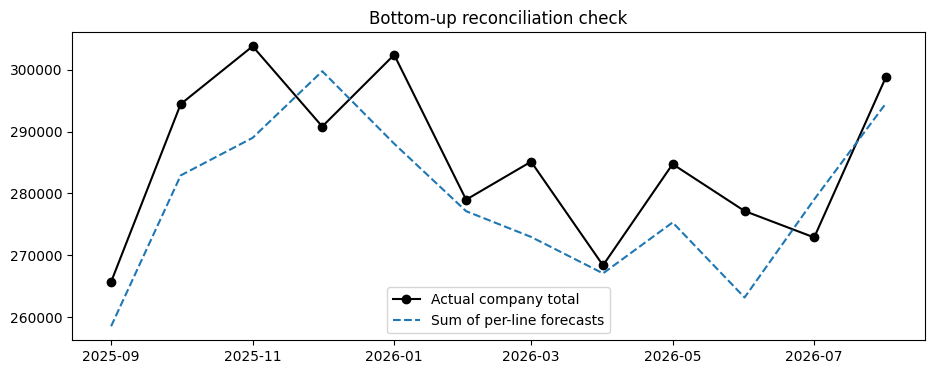

In [17]:
# Reconciliation check: does summing the per-line forecasts approximate the
# independently-modeled company total?
test_s_pred_df = test_s[["date", "service_line"]].copy()
test_s_pred_df["pred"] = service_revenue_pred
recon = test_s_pred_df.groupby("date", observed=True)["pred"].sum().reset_index()
recon = recon.merge(test_c[["date", flib.COMPANY_TARGET_COL]], on="date", how="inner")
recon_metrics = flib.regression_metrics(recon[flib.COMPANY_TARGET_COL], recon["pred"])
print("Sum-of-lines vs. company-total MAPE:", recon_metrics)

fig, ax = plt.subplots()
ax.plot(recon["date"], recon[flib.COMPANY_TARGET_COL], "o-", label="Actual company total", color="black")
ax.plot(recon["date"], recon["pred"], "--", label="Sum of per-line forecasts")
ax.legend()
ax.set_title("Bottom-up reconciliation check")
plt.show()


Summing the per-line forecasts actually reconciles to the company total *better*
than either the direct company-level XGBoost model or matches SARIMAX closely —
errors in individual service lines partly cancel out when aggregated. This is a
classic hierarchical-forecasting result and is worth keeping in mind if this were
a real deployment: a bottom-up forecast can be more robust than a top-down one.


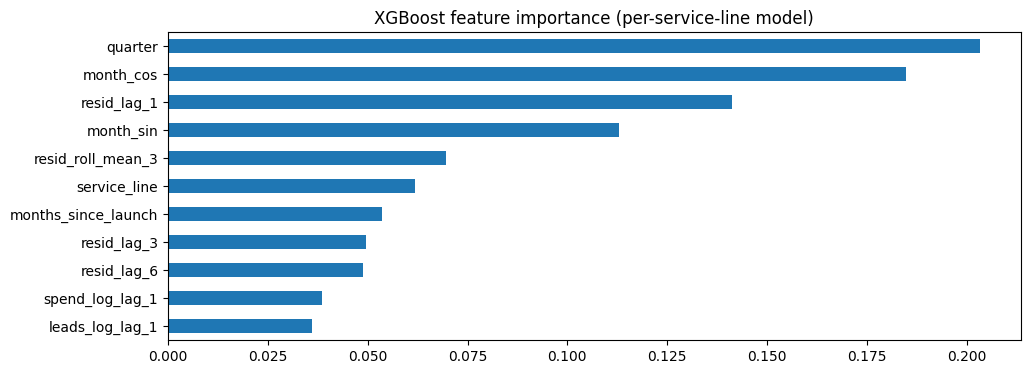

In [18]:
# Feature importance for the per-service-line model
importances = pd.Series(xgb_service.feature_importances_, index=flib.SERVICE_FEATURE_COLS).sort_values()
importances.plot(kind="barh", title="XGBoost feature importance (per-service-line model)")
plt.show()


## 5. Refit on all data, forecast forward, and persist deployment artifacts

In [19]:
# Refit the trend + XGBoost on the FULL history (train+holdout) for the version we deploy.
company_trend_final = flib.fit_trend(np.arange(len(df_company)), df_company[flib.COMPANY_TARGET_COL].to_numpy())
feat_company_final = flib.build_company_features(df_company, company_trend_final)
feat_company_final_model = feat_company_final.dropna(subset=flib.COMPANY_FEATURE_COLS).reset_index(drop=True)

xgb_company_final = XGBRegressor(
    n_estimators=300, max_depth=3, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42,
)
xgb_company_final.fit(
    feat_company_final_model[flib.COMPANY_FEATURE_COLS], feat_company_final_model[flib.COMPANY_RESID_COL]
)

service_trends_final = flib.fit_service_trends(df_service_post, holdout_months=0)
feat_service_final = flib.build_service_features(df_service, service_trends_final)

xgb_service_final = XGBRegressor(
    n_estimators=400, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42,
    enable_categorical=True, tree_method="hist",
)
xgb_service_final.fit(
    feat_service_final[flib.SERVICE_FEATURE_COLS], feat_service_final[flib.SERVICE_RESID_COL]
)
print("Refit complete.")


Refit complete.


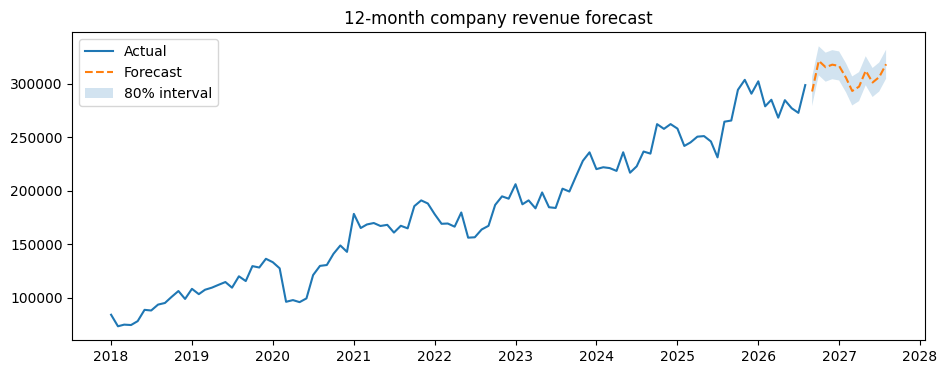

,date,forecast_revenue_usd,lower_80,upper_80
0,2026-09-01,292881.906095,279282.433263,306481.378928
1,2026-10-01,321608.361764,308008.888932,335207.834597
2,2026-11-01,315629.961462,302030.488630,329229.434295
3,2026-12-01,317997.297707,304397.824874,331596.770539
4,2027-01-01,316788.756378,303189.283545,330388.229210
5,2027-02-01,305705.497321,292106.024488,319304.970153
6,2027-03-01,293392.833960,279793.361128,306992.306793
7,2027-04-01,297433.202078,283833.729246,311032.674911
8,2027-05-01,312292.893506,298693.420673,325892.366338
9,2027-06-01,301309.903793,287710.430961,314909.376626


In [20]:
# 12-month company forecast, with prediction interval approximated from the
# holdout residual spread (a simple, transparent way to show uncertainty).
future = flib.recursive_forecast_company(xgb_company_final, company_trend_final, df_company, horizon=12)

resid_std = np.std(test_c[flib.COMPANY_TARGET_COL].to_numpy() - xgb_revenue_pred)
future["lower_80"] = (future["forecast_revenue_usd"] - 1.28 * resid_std).clip(lower=0)
future["upper_80"] = future["forecast_revenue_usd"] + 1.28 * resid_std

fig, ax = plt.subplots()
ax.plot(df_company["date"], df_company["total_revenue_usd"], label="Actual")
ax.plot(future["date"], future["forecast_revenue_usd"], "--", label="Forecast")
ax.fill_between(future["date"], future["lower_80"], future["upper_80"], alpha=0.2, label="80% interval")
ax.legend()
ax.set_title("12-month company revenue forecast")
plt.show()

future


In [21]:
import os
os.makedirs("artifacts", exist_ok=True)

joblib.dump(xgb_company_final, "artifacts/company_model.pkl")
joblib.dump(company_trend_final, "artifacts/company_trend.pkl")
joblib.dump(xgb_service_final, "artifacts/service_model.pkl")
joblib.dump(service_trends_final, "artifacts/service_trends.pkl")

flib.save_json(
    {
        "company_feature_cols": flib.COMPANY_FEATURE_COLS,
        "service_feature_cols": flib.SERVICE_FEATURE_COLS,
        "holdout_months": HOLDOUT,
        "model_comparison": comparison.to_dict(orient="index"),
        "winner_by_mape": comparison["MAPE_%"].idxmin(),
        "deployed_model": "XGBoost (trend+residual) — chosen for scenario-planning support; see write-up above",
        "service_model_metrics": service_metrics,
        "reconciliation_metrics": recon_metrics,
        "holdout_residual_std_usd": float(resid_std),
        "trained_through_date": str(df_company["date"].max().date()),
    },
    "artifacts/metrics.json",
)
print("Saved artifacts/ — ready for app.py")


Saved artifacts/ — ready for app.py


## 6. Summary

- **Naive vs. SARIMAX vs. XGBoost** were compared on a strict 12-month, time-based
  holdout (no shuffling, no leakage — see the design note in Section 2).
- **SARIMAX had the lowest holdout MAPE** on this series. **XGBoost was still chosen
  for deployment** because it supports scenario inputs (spend/leads what-ifs) via
  its feature set, which SARIMAX (as configured here) doesn't.
- A **per-service-line XGBoost model** was also built; summing its forecasts
  reconciles closely to the independently-forecast company total, which is a
  useful sanity check and lets the app forecast any single service line, including
  the short-history GEO/AEO line.
- All deployment artifacts (`company_model.pkl`, `company_trend.pkl`,
  `service_model.pkl`, `service_trends.pkl`, `metrics.json`) are saved to
  `artifacts/` for `app.py` to load without retraining.
